# CIFAR10

## nn.Sequential --> fonction

## nn.Dropout --> couche

In [25]:
import os

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.tensorboard import SummaryWriter

torch.cuda.is_available()

False

In [26]:
from torchvision.transforms import ToTensor

dataset_train = torchvision.datasets.CIFAR10(
    root='./data_cifar_10',
    train= True,
    transform=ToTensor(),
    download=True,
)
dataset_test = torchvision.datasets.CIFAR10(
    root='./data_cifar_10',
    train= False,
    transform=ToTensor(),
    download=True,
)

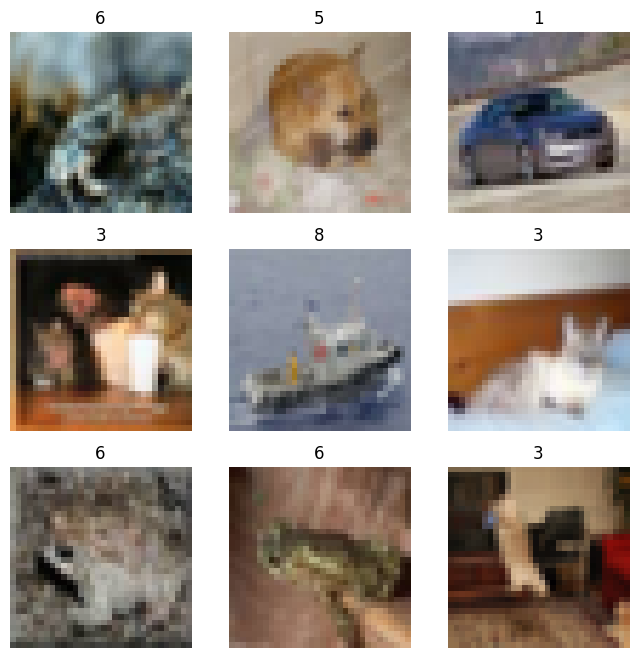

In [27]:
figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3
for i in range(1, cols*rows+1):
    sample_idx = torch.randint(len(dataset_train), size=(1,)).item()
    img, label = dataset_train[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))
plt.show()

In [28]:
from torch.utils.data import DataLoader

dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

In [29]:
train_features, train_labels = next(iter(dataloader_train))
train_features.size()

torch.Size([64, 3, 32, 32])

In [30]:
from torch import nn

def forward():
    features = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((1, 1))
    )

    classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 10)
    )

    return nn.Sequential(features, classifier)


In [31]:
mlp = forward()

print(mlp)

n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"\n[2.3] Paramètres entraînables : {n_params:,}")

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (1): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.

In [32]:
# x_dummy = torch.randn(1, 3, 32, 32)
# output = mlp(x_dummy)
# print(f"\n[2.4] Forward pass : entrée {x_dummy.shape} --> {output.shape}")
# print(f"Sortie : {output}")

In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3)

In [34]:
log_dir = os.path.join("runs", "atelier4")
writer = SummaryWriter(log_dir=log_dir)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
    "batch_step": [],
    "batch_loss": [],
    "batch_acc": [],
}

global_step = 0

In [35]:
def train_loop(dataloader, model, loss_fn, optimizer, writer=None, history=None, global_step=0):
    size = len(dataloader.dataset)
    model.train()
    num_batches = len(dataloader)
    running_loss = 0.0
    running_correct = 0
    loop = tqdm(enumerate(dataloader), total=num_batches, desc="Train", leave=False)
    for batch, (X, y_true) in loop:
        y_pred = model(X)
        loss = loss_fn(y_pred, y_true)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        batch_loss = loss.item()
        batch_correct = (y_pred.argmax(1) == y_true).sum().item()
        batch_acc = batch_correct / X.size(0)
        running_loss += batch_loss
        running_correct += batch_correct

        if writer is not None:
            writer.add_scalar("Batch/Loss", batch_loss, global_step)
            writer.add_scalar("Batch/Accuracy", batch_acc, global_step)
        if history is not None:
            history["batch_step"].append(global_step)
            history["batch_loss"].append(batch_loss)
            history["batch_acc"].append(batch_acc)

        # Met à jour la barre et affiche la perte actuelle
        current = batch * getattr(dataloader, 'batch_size', X.size(0)) + X.size(0)
        loop.set_postfix({'loss': f"{batch_loss:.4f}", 'samples': f"{current}/{size}"})
        global_step += 1

    avg_loss = running_loss / num_batches
    accuracy = running_correct / size
    return avg_loss, accuracy, global_step


def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    loop = tqdm(enumerate(dataloader), total=num_batches, desc="Test", leave=False)
    with torch.no_grad():
        for batch, (X, y_true) in loop:
            y_pred = model(X)
            test_loss += loss_fn(y_pred, y_true).item()
            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()
            avg_loss = test_loss / (batch + 1)
            acc = correct / ((batch + 1) * getattr(dataloader, 'batch_size', X.size(0)))
            loop.set_postfix({'avg_loss': f"{avg_loss:.4f}", 'acc': f"{100*acc:.1f}%"})
    
    test_loss /= num_batches
    correct /= size

    return test_loss, correct


def plot_epoch_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
    axes[0].plot(history["epoch"], history["test_loss"], marker="o", label="test")
    axes[0].set_title("Loss par epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_acc"], marker="o", label="train")
    axes[1].plot(history["epoch"], history["test_acc"], marker="o", label="test")
    axes[1].set_title("Accuracy par epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    return fig


def plot_batch_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["batch_step"], history["batch_loss"], color="tab:blue", linewidth=1)
    axes[0].set_title("Loss tout du long")
    axes[0].set_xlabel("Batch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history["batch_step"], history["batch_acc"], color="tab:orange", linewidth=1)
    axes[1].set_title("Accuracy tout du long")
    axes[1].set_xlabel("Batch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    return fig

In [36]:
epochs = 5
global_step = 0
for epoch in range(epochs):
    epoch_index = epoch + 1
    print("Epoch :", epoch_index)

    train_loss, train_acc, global_step = train_loop(
        dataloader_train,
        mlp,
        criterion,
        optimizer,
        writer=writer,
        history=history,
        global_step=global_step,
    )
    test_loss, test_acc = test_loop(dataloader_test, mlp, criterion)

    history["epoch"].append(epoch_index)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"  train - loss: {train_loss:.4f}, acc: {100 * train_acc:.2f}% | ",
        f"test - loss: {test_loss:.4f}, acc: {100 * test_acc:.2f}%"
    )

    writer.add_scalars("Epoch/Loss", {"train": train_loss, "test": test_loss}, epoch_index)
    writer.add_scalars("Epoch/Accuracy", {"train": train_acc, "test": test_acc}, epoch_index)

    epoch_fig = plot_epoch_history(history)
    writer.add_figure("Figures/Epoch overview", epoch_fig, global_step=epoch_index)
    plt.show()
    plt.close(epoch_fig)
    writer.flush()

batch_fig = plot_batch_history(history)
writer.add_figure("Figures/Batch overview", batch_fig, global_step=global_step)
plt.show()
plt.close(batch_fig)
writer.flush()
writer.close()

print("Done")
print(f"TensorBoard logs : {log_dir}")
print("Run 'tensorboard --logdir=runs'")

Epoch : 1


  train - loss: 1.6671, acc: 35.67% |  test - loss: 1.4940, acc: 43.71%
Epoch : 2


  train - loss: 1.3380, acc: 51.26% |  test - loss: 1.1664, acc: 56.76%
Epoch : 3


  train - loss: 1.1806, acc: 57.31% |  test - loss: 1.2223, acc: 55.53%
Epoch : 4


  train - loss: 1.0748, acc: 61.39% |  test - loss: 1.2996, acc: 55.77%
Epoch : 5


  train - loss: 1.0051, acc: 63.96% |  test - loss: 1.0486, acc: 61.66%
Done
TensorBoard logs : runs/atelier4
Run 'tensorboard --logdir=runs'


In [37]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18()


In [38]:
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_params

11689512

In [39]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)

In [40]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [41]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [42]:
params_entrainables_apres_gel = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParamètres entraînables après gel : {params_entrainables_apres_gel}")


Paramètres entraînables après gel : 11689512


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

train - loss: 1.7442, acc: 38.94% | test - loss: 1.6509, acc: 42.84%
Epoch 2/3


train - loss: 1.6148, acc: 43.53% | test - loss: 1.6003, acc: 45.02%
Epoch 3/3


train - loss: 1.5988, acc: 44.14% | test - loss: 1.5786, acc: 45.85%


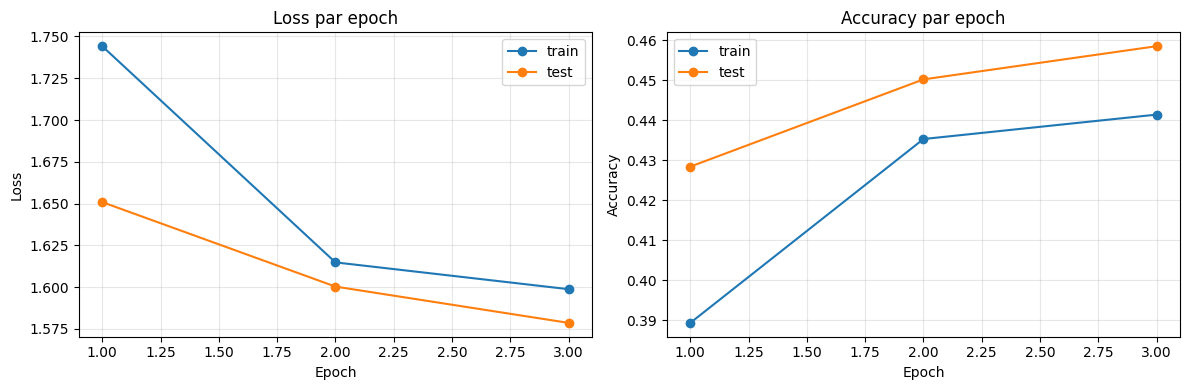

In [44]:
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

model.fc = nn.Linear(model.fc.in_features, 10)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=1e-3)

print(model)
print(f"Paramètres entraînables: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

history_resnet = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

epochs_resnet = 3
global_step_resnet = 0
for epoch in range(epochs_resnet):
    epoch_index = epoch + 1
    print(f"Epoch {epoch_index}/{epochs_resnet}")

    train_loss, train_acc, global_step_resnet = train_loop(
        dataloader_train,
        model,
        criterion,
        optimizer,
        writer=None,
        history=None,
        global_step=global_step_resnet,
    )
    test_loss, test_acc = test_loop(dataloader_test, model, criterion)

    history_resnet["epoch"].append(epoch_index)
    history_resnet["train_loss"].append(train_loss)
    history_resnet["train_acc"].append(train_acc)
    history_resnet["test_loss"].append(test_loss)
    history_resnet["test_acc"].append(test_acc)

    print(
        f"train - loss: {train_loss:.4f}, acc: {100 * train_acc:.2f}% | "
        f"test - loss: {test_loss:.4f}, acc: {100 * test_acc:.2f}%"
    )

fig_resnet = plot_epoch_history(history_resnet)
plt.show()
plt.close(fig_resnet)